01. Environment Check
Python  : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
OS      : Windows 10
PyTorch : 2.6.0+cu124
CUDA    : True
GPU     : NVIDIA GeForce RTX 4060 Ti
02. Package installation complete.
03. All libraries imported successfully.
04. Config set. Best model: xcep_rgb_fft_phy
05. Best model loaded: xcep_rgb_fft_phy
06. Test set loaded: 54,000 samples
07. Inference helper defined.

EXP-02. Robustness Test
  Already computed. Loaded from exp02_robustness.csv
   Perturbation    AUC  Accuracy     F1
No Perturbation 0.9995    0.9906 0.9920
      JPEG Q=90 0.9983    0.9800 0.9829
      JPEG Q=70 0.9858    0.9289 0.9416
      JPEG Q=50 0.9547    0.8793 0.9003
      JPEG Q=30 0.9014    0.8132 0.8402
 GaussNoise σ=5 0.9666    0.6728 0.6106
GaussNoise σ=15 0.7447    0.4408 0.0809
GaussNoise σ=25 0.5671    0.4182 0.0059
     Resize×0.5 0.8599    0.7269 0.6951
    Resize×0.75 0.9637    0.7983 0.7912
       Blur k=3 0.8687    0.730

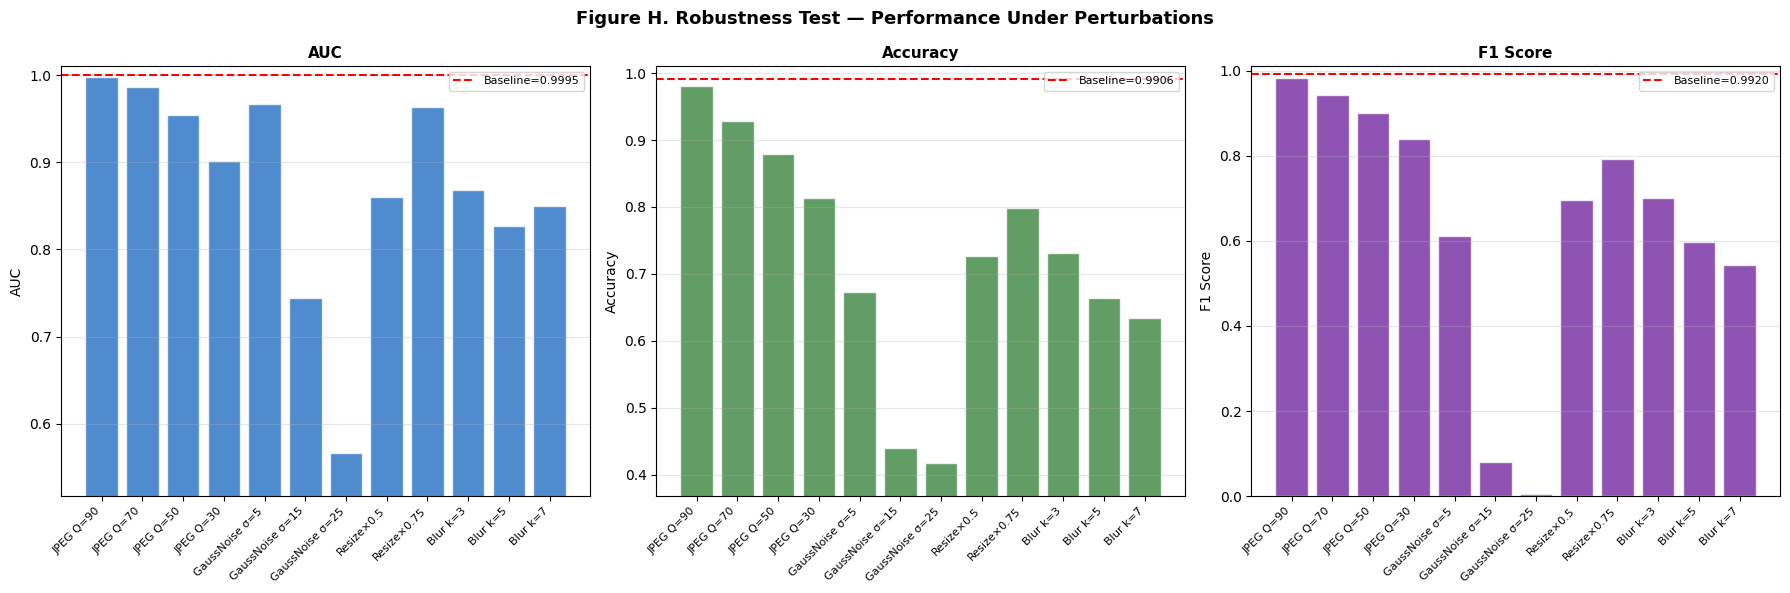

  Saved → eda_outputs/FigH_robustness.png

EXP-03. Threshold Sensitivity Analysis
 Threshold  Accuracy  Precision  Recall     F1
      0.05    0.9865     0.9798  0.9975 0.9885
      0.10    0.9882     0.9835  0.9964 0.9899
      0.15    0.9890     0.9855  0.9958 0.9907
      0.20    0.9895     0.9868  0.9953 0.9910
      0.25    0.9899     0.9881  0.9948 0.9914
      0.30    0.9900     0.9888  0.9942 0.9915
      0.35    0.9901     0.9893  0.9937 0.9915
      0.40    0.9902     0.9899  0.9933 0.9916
      0.45    0.9904     0.9907  0.9928 0.9917
      0.50    0.9906     0.9912  0.9927 0.9920
      0.55    0.9905     0.9914  0.9923 0.9918
      0.60    0.9904     0.9919  0.9917 0.9918
      0.65    0.9906     0.9923  0.9915 0.9919
      0.70    0.9907     0.9930  0.9910 0.9920
      0.75    0.9904     0.9936  0.9899 0.9917
      0.80    0.9899     0.9943  0.9883 0.9913
      0.85    0.9895     0.9953  0.9867 0.9909
      0.90    0.9879     0.9959  0.9832 0.9895
      0.95    0.9850     

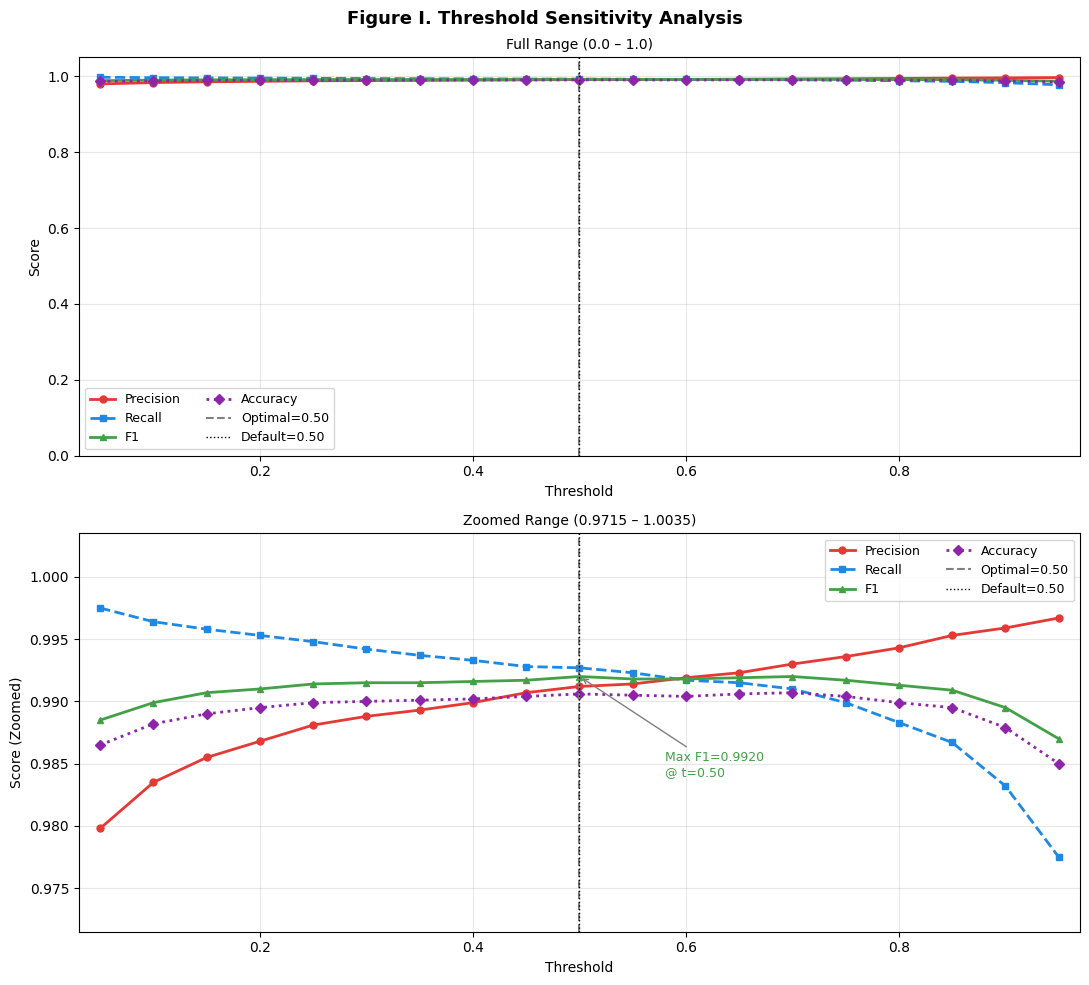

  Optimal threshold: 0.50 (F1=0.9920)
  Saved → eda_outputs/FigI_threshold_sensitivity.png

EXP-05. Source-Specific Performance Analysis
  DFF      (N=18,026) → AUC:0.9983 Acc:0.9849 F1:0.9899
  140k     (N=17,911) → AUC:1.0000 Acc:0.9997 F1:0.9997
  CIFAKE   (N=18,063) → AUC:0.9992 Acc:0.9874 F1:0.9873

  Saved → robustness_outputs/exp05_source_specific.csv


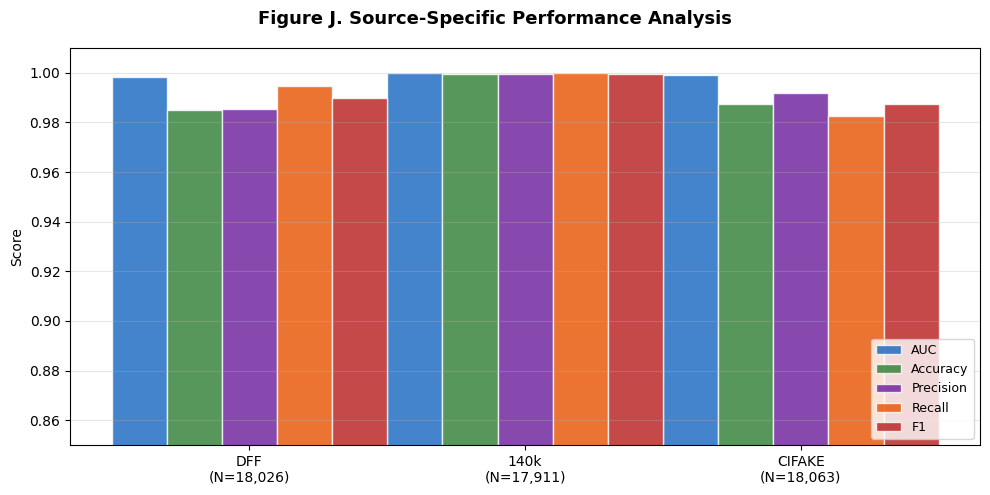

  Saved → eda_outputs/FigJ_source_specific.png

EXP-06. Fake-Type Specific Performance (DFF Subsets)
  Inpainting (SD)           (N=4,542) → AUC:0.9994 Acc:0.9887 F1:0.9672
  InsightFace (GAN)         (N=4,440) → AUC:0.9998 Acc:0.9895 F1:0.9691
  Text2Image (SD)           (N=4,487) → AUC:0.9993 Acc:0.9883 F1:0.9657
  StyleGAN (140k)           (N=9,026) → AUC:1.0000 Acc:0.9912 F1:0.9848
  StyleGAN (CIFAKE)         (N=9,005) → AUC:0.9990 Acc:0.9863 F1:0.9762

  Saved → robustness_outputs/exp06_fake_type.csv


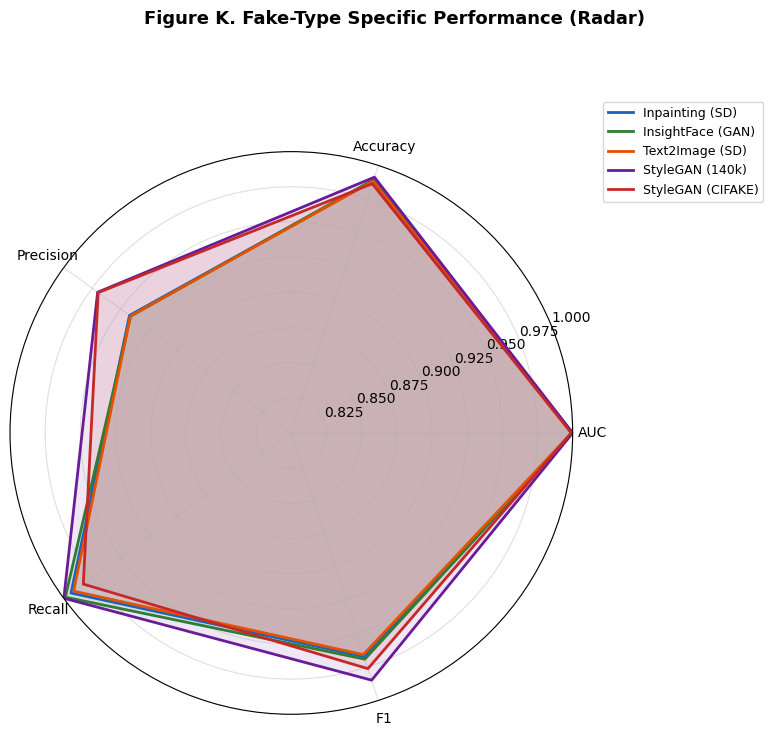

  Saved → eda_outputs/FigK_fake_type_radar.png

08. Robustness Summary Report

  [EXP-02] Robustness — Max Performance Drop:
    Worst AUC drop : GaussNoise σ=25 (ΔAUC = -0.4324)
    Worst Acc drop : GaussNoise σ=25 (ΔAcc = -0.5724)

  [EXP-03] Optimal Threshold: 0.50 (F1=0.9920 vs default 0.5 F1=0.9920)

  [EXP-05] Source-Specific AUC:
    DFF      → AUC:0.9983
    140k     → AUC:1.0000
    CIFAKE   → AUC:0.9992

  [EXP-06] Fake-Type AUC:
    Inpainting (SD)                → AUC:0.9994
    InsightFace (GAN)              → AUC:0.9998
    Text2Image (SD)                → AUC:0.9993
    StyleGAN (140k)                → AUC:1.0000
    StyleGAN (CIFAKE)              → AUC:0.9990

  Saved → robustness_outputs/robustness_summary.csv

ALL ROBUSTNESS EXPERIMENTS COMPLETE.

Outputs:
  robustness_outputs/exp02_robustness.csv
  robustness_outputs/exp03_threshold.csv
  robustness_outputs/exp05_source_specific.csv
  robustness_outputs/exp06_fake_type.csv
  robustness_outputs/robustness_summary.csv


In [6]:
# =============================================================
# Notebook Name: 05_robustness.ipynb
# Project     : Multi-Stream Deepfake Detection (SFRPD-Net Extension)
# Experiments : EXP-02 Robustness | EXP-03 Threshold | 
#               EXP-05 Source-Specific | EXP-06 Fake-Type Specific
# =============================================================

# ─────────────────────────────────────────
# 01. Environment Check
# ─────────────────────────────────────────
import sys, torch, platform

print("=" * 50)
print("01. Environment Check")
print("=" * 50)
print(f"Python  : {sys.version}")
print(f"OS      : {platform.system()} {platform.release()}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print("=" * 50)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ─────────────────────────────────────────
# 02. Install Required Packages
# ─────────────────────────────────────────
import subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

pip_install("scikit-learn")
pip_install("matplotlib")
pip_install("seaborn")
pip_install("pandas")
pip_install("timm")
pip_install("albumentations")
pip_install("opencv-python")
print("02. Package installation complete.")


# ─────────────────────────────────────────
# 03. Import Libraries
# ─────────────────────────────────────────
import warnings, random
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from sklearn.metrics import (
    roc_curve, auc as sk_auc,
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report,
)

import torch
import torch.nn as nn
import torchvision.models as models
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from PIL import Image

print("03. All libraries imported successfully.")


# ─────────────────────────────────────────
# 04. Paths & Configuration
# ─────────────────────────────────────────
IMG_SIZE    = 299
BATCH_SIZE  = 32
RANDOM_SEED = 42

EXPORT_DIR = Path("./export")
SPLIT_DIR  = Path("./processed/splits")
TRACK1_DIR = Path("./processed/track1_face")
TRACK2_DIR = Path("./processed/track2_fullscene")
CKPT_DIR   = Path("./checkpoints")
EDA_DIR    = Path("./eda_outputs")
ROB_DIR    = Path("./robustness_outputs")

for d in [EDA_DIR, ROB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

BEST_MODEL_NAME = "xcep_rgb_fft_phy"
BEST_BACKBONE   = "xception"
BEST_STREAMS    = ["rgb", "fft", "phy"]

print(f"04. Config set. Best model: {BEST_MODEL_NAME}")


# ─────────────────────────────────────────
# 05. Model Definition & Load Best Model
# ─────────────────────────────────────────
def build_backbone(backbone_name: str, out_dim: int = 256) -> nn.Module:
    if backbone_name == "vgg16":
        base = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_f = base.classifier[0].in_features
        base.classifier = nn.Sequential(
            nn.Linear(in_f, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, out_dim), nn.ReLU(),
        )
    elif backbone_name == "xception":
        base = timm.create_model("xception", pretrained=False, num_classes=0)
        in_f = base.num_features
        base = nn.Sequential(
            base,
            nn.Linear(in_f, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, out_dim), nn.ReLU(),
        )
    return base


class SFRPDNet(nn.Module):
    def __init__(self, backbone, stream_dim=256,
                 active_streams=["rgb", "fft", "phy"]):
        super().__init__()
        self.active_streams = active_streams
        if "rgb" in active_streams:
            self.rgb_stream = build_backbone(backbone, stream_dim)
        if "fft" in active_streams:
            self.fft_stream = build_backbone(backbone, stream_dim)
        if "phy" in active_streams:
            self.phy_stream = build_backbone(backbone, stream_dim)
        self.gates = nn.ParameterDict({
            s: nn.Parameter(torch.ones(1)) for s in active_streams
        })
        fused_dim = stream_dim * len(active_streams)
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 64),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, batch):
        feats = []
        if "rgb" in self.active_streams:
            feats.append(torch.sigmoid(self.gates["rgb"]) *
                         self.rgb_stream(batch["rgb"]))
        if "fft" in self.active_streams:
            feats.append(torch.sigmoid(self.gates["fft"]) *
                         self.fft_stream(batch["fft"]))
        if "phy" in self.active_streams:
            feats.append(torch.sigmoid(self.gates["phy"]) *
                         self.phy_stream(batch["phy"]))
        return self.classifier(torch.cat(feats, dim=1))


best_model = SFRPDNet(BEST_BACKBONE,
                      active_streams=BEST_STREAMS).to(DEVICE)
ckpt = CKPT_DIR / f"{BEST_MODEL_NAME}_best.pt"
best_model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
best_model.eval()
print(f"05. Best model loaded: {BEST_MODEL_NAME}")


# ─────────────────────────────────────────
# 06. Base Dataset Class
# ─────────────────────────────────────────
class DeepfakeDataset(Dataset):
    def __init__(self, df, transform=None, perturbation_fn=None):
        self.df   = df.reset_index(drop=True)
        self.tf   = transform
        self.perturb = perturbation_fn   # applied to raw numpy image

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        return np.array(Image.open(path).convert("RGB"))

    def _fft(self, img):
        fft_ch = []
        for c in range(3):
            ch  = img[:, :, c].astype(np.float32)
            mag = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(ch))))
            mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
            fft_ch.append((mag * 255).astype(np.uint8))
        return np.stack(fft_ch, axis=-1)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = torch.tensor(row["label"], dtype=torch.long)
        t1    = self._load(row["track1_path"])
        t2    = self._load(row["track2_path"])

        if self.perturb:
            t1 = self.perturb(t1)
            t2 = self.perturb(t2)

        rgb = self.tf(image=t1)["image"]
        fft = self.tf(image=self._fft(t1))["image"]
        phy = self.tf(image=t2)["image"]
        return {"rgb": rgb, "fft": fft, "phy": phy, "label": label}


EVAL_TF = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

df_test = pd.read_csv(SPLIT_DIR / "test.csv")
print(f"06. Test set loaded: {len(df_test):,} samples")


# ─────────────────────────────────────────
# 07. Inference Helper
# ─────────────────────────────────────────
@torch.no_grad()
def run_inference(model, loader):
    """Return (labels, probs, preds) arrays."""
    all_labels, all_probs, all_preds = [], [], []
    for batch in tqdm(loader, desc="  Inference", leave=False):
        x = {k: v.to(DEVICE) for k, v in batch.items() if k != "label"}
        y = batch["label"]
        out  = model(x)
        prob = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        pred = out.argmax(1).cpu().numpy()
        all_labels.extend(y.numpy())
        all_probs.extend(prob)
        all_preds.extend(pred)
    return (np.array(all_labels),
            np.array(all_probs),
            np.array(all_preds))


def compute_metrics(labels, probs, preds) -> dict:
    fpr, tpr, _ = roc_curve(labels, probs)
    return {
        "AUC"      : round(sk_auc(fpr, tpr), 4),
        "Accuracy" : round(accuracy_score(labels, preds), 4),
        "Precision": round(precision_score(labels, preds,
                                           zero_division=0), 4),
        "Recall"   : round(recall_score(labels, preds,
                                        zero_division=0), 4),
        "F1"       : round(f1_score(labels, preds,
                                    zero_division=0), 4),
    }

print("07. Inference helper defined.")


# ═══════════════════════════════════════════════════════════════
# EXP-02. Robustness Test
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("EXP-02. Robustness Test")
print("=" * 60)

# ── Perturbation functions ──
def jpeg_compress(img: np.ndarray, quality: int) -> np.ndarray:
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    _, enc  = cv2.imencode(".jpg", img_bgr,
                           [cv2.IMWRITE_JPEG_QUALITY, quality])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)

def gaussian_noise(img: np.ndarray, sigma: float) -> np.ndarray:
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def resize_restore(img: np.ndarray, scale: float) -> np.ndarray:
    h, w   = img.shape[:2]
    small  = cv2.resize(img, (int(w*scale), int(h*scale)))
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_LANCZOS4)

def gaussian_blur(img: np.ndarray, ksize: int) -> np.ndarray:
    return cv2.GaussianBlur(img, (ksize, ksize), 0)

# ── Perturbation matrix ──
perturbations = [
    ("No Perturbation",   None),
    ("JPEG Q=90",  lambda x: jpeg_compress(x, 90)),
    ("JPEG Q=70",  lambda x: jpeg_compress(x, 70)),
    ("JPEG Q=50",  lambda x: jpeg_compress(x, 50)),
    ("JPEG Q=30",  lambda x: jpeg_compress(x, 30)),
    ("GaussNoise σ=5",  lambda x: gaussian_noise(x, 5)),
    ("GaussNoise σ=15", lambda x: gaussian_noise(x, 15)),
    ("GaussNoise σ=25", lambda x: gaussian_noise(x, 25)),
    ("Resize×0.5", lambda x: resize_restore(x, 0.5)),
    ("Resize×0.75",lambda x: resize_restore(x, 0.75)),
    ("Blur k=3",   lambda x: gaussian_blur(x, 3)),
    ("Blur k=5",   lambda x: gaussian_blur(x, 5)),
    ("Blur k=7",   lambda x: gaussian_blur(x, 7)),
]

rob_csv = ROB_DIR / "exp02_robustness.csv"

if rob_csv.exists():
    df_rob = pd.read_csv(rob_csv)
    print(f"  Already computed. Loaded from {rob_csv.name}")
    print(df_rob[["Perturbation","AUC","Accuracy","F1"]].to_string(index=False))
else:
    rob_rows = []
    for name, perturb_fn in perturbations:
        ds     = DeepfakeDataset(df_test, EVAL_TF, perturb_fn)
        loader = DataLoader(ds, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=0, pin_memory=True)
        labels, probs, preds = run_inference(best_model, loader)
        m = compute_metrics(labels, probs, preds)
        m["Perturbation"] = name
        rob_rows.append(m)
        print(f"  {name:25s} → AUC:{m['AUC']:.4f} "
              f"Acc:{m['Accuracy']:.4f} F1:{m['F1']:.4f}")

    df_rob = pd.DataFrame(rob_rows)[
        ["Perturbation","AUC","Accuracy","Precision","Recall","F1"]]
    df_rob.to_csv(rob_csv, index=False)
    print(f"\n  Saved → robustness_outputs/exp02_robustness.csv")


# ── Figure H: Robustness Bar Chart ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Figure H. Robustness Test — Performance Under Perturbations",
             fontsize=13, fontweight="bold")

baseline = df_rob[df_rob["Perturbation"]=="No Perturbation"]
bl_auc   = baseline["AUC"].values[0]
bl_acc   = baseline["Accuracy"].values[0]
bl_f1    = baseline["F1"].values[0]

df_rob_plot = df_rob[df_rob["Perturbation"] != "No Perturbation"]
labels_plot = df_rob_plot["Perturbation"].tolist()
x = np.arange(len(labels_plot))

for ax, metric, bl, title, col in [
    (axes[0], "AUC",      bl_auc, "AUC",      "#1565C0"),
    (axes[1], "Accuracy", bl_acc, "Accuracy", "#2E7D32"),
    (axes[2], "F1",       bl_f1,  "F1 Score", "#6A1B9A"),
]:
    bars = ax.bar(x, df_rob_plot[metric].values,
                  color=col, alpha=0.75, edgecolor="white")
    ax.axhline(bl, color="red", lw=1.5, linestyle="--",
               label=f"Baseline={bl:.4f}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels_plot, rotation=45,
                       ha="right", fontsize=8)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylim(max(0, df_rob_plot[metric].min() - 0.05), 1.01)
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigH_robustness.png", dpi=300, bbox_inches="tight")
plt.show()
print("  Saved → eda_outputs/FigH_robustness.png")


# ═══════════════════════════════════════════════════════════════
# EXP-03. Threshold Sensitivity Analysis
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("EXP-03. Threshold Sensitivity Analysis")
print("=" * 60)

# Reuse base predictions (no perturbation)
df_base_pred = pd.read_csv(EXPORT_DIR /
                           f"{BEST_MODEL_NAME}_test_predictions.csv")
y_true = df_base_pred["label"].values
y_prob = df_base_pred["prob_fake"].values

thresholds  = np.arange(0.05, 0.96, 0.05)
thresh_rows = []
for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    thresh_rows.append({
        "Threshold" : round(t, 2),
        "Accuracy"  : round(accuracy_score(y_true, y_pred), 4),
        "Precision" : round(precision_score(y_true, y_pred,
                                            zero_division=0), 4),
        "Recall"    : round(recall_score(y_true, y_pred,
                                         zero_division=0), 4),
        "F1"        : round(f1_score(y_true, y_pred,
                                     zero_division=0), 4),
    })

df_thresh = pd.DataFrame(thresh_rows)
df_thresh.to_csv(ROB_DIR / "exp03_threshold.csv", index=False)
print(df_thresh.to_string(index=False))
print("\n  Saved → robustness_outputs/exp03_threshold.csv")

# ── Figure I: Threshold Sensitivity ──
fig, axes = plt.subplots(2, 1, figsize=(11, 10))
fig.suptitle("Figure I. Threshold Sensitivity Analysis",
             fontsize=13, fontweight="bold")

styles = [
    ("Precision", "#e53935", "-",  "o"),
    ("Recall",    "#1e88e5", "--", "s"),
    ("F1",        "#43a047", "-",  "^"),
    ("Accuracy",  "#8e24aa", ":",  "D"),
]

# ── Top panel: full range ──
ax0 = axes[0]
for metric, col, ls, mk in styles:
    ax0.plot(df_thresh["Threshold"], df_thresh[metric],
             color=col, lw=2, linestyle=ls,
             marker=mk, ms=5, label=metric)
ax0.axvline(opt_t, color="gray", lw=1.5, linestyle="--",
            label=f"Optimal={opt_t:.2f}")
ax0.axvline(0.5,   color="black", lw=1, linestyle=":",
            label="Default=0.50")
ax0.set_xlabel("Threshold", fontsize=10)
ax0.set_ylabel("Score", fontsize=10)
ax0.set_title("Full Range (0.0 – 1.0)", fontsize=10)
ax0.set_xlim([0.03, 0.97])
ax0.set_ylim([0.0, 1.05])
ax0.legend(fontsize=9, ncol=2)
ax0.grid(True, alpha=0.3)

# ── Bottom panel: zoomed range ──
ax1 = axes[1]
y_min = df_thresh[["Precision","Recall","F1","Accuracy"]].values.min()
y_max = df_thresh[["Precision","Recall","F1","Accuracy"]].values.max()
margin = (y_max - y_min) * 0.3

for metric, col, ls, mk in styles:
    ax1.plot(df_thresh["Threshold"], df_thresh[metric],
             color=col, lw=2, linestyle=ls,
             marker=mk, ms=5, label=metric)
ax1.axvline(opt_t, color="gray", lw=1.5, linestyle="--",
            label=f"Optimal={opt_t:.2f}")
ax1.axvline(0.5,   color="black", lw=1, linestyle=":",
            label="Default=0.50")

# Annotate max F1
ax1.annotate(f"Max F1={opt_f1:.4f}\n@ t={opt_t:.2f}",
             xy=(opt_t, opt_f1),
             xytext=(opt_t + 0.08,
                     opt_f1 - (y_max - y_min) * 0.4),
             arrowprops=dict(arrowstyle="->", color="gray"),
             fontsize=9, color="#43a047")

ax1.set_xlabel("Threshold", fontsize=10)
ax1.set_ylabel("Score (Zoomed)", fontsize=10)
ax1.set_title(f"Zoomed Range ({y_min-margin:.4f} – {y_max+margin:.4f})",
              fontsize=10)
ax1.set_xlim([0.03, 0.97])
ax1.set_ylim([y_min - margin, y_max + margin])
ax1.legend(fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigI_threshold_sensitivity.png",
            dpi=300, bbox_inches="tight")
plt.show()
print(f"  Optimal threshold: {opt_t:.2f} (F1={opt_f1:.4f})")
print("  Saved → eda_outputs/FigI_threshold_sensitivity.png")


# ═══════════════════════════════════════════════════════════════
# EXP-05. Source-Specific Performance Analysis
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("EXP-05. Source-Specific Performance Analysis")
print("=" * 60)

# Merge predictions with source labels from split CSV
df_test_src = pd.read_csv(SPLIT_DIR / "test.csv")
df_pred_src = pd.read_csv(
    EXPORT_DIR / f"{BEST_MODEL_NAME}_test_predictions.csv")
df_pred_src["source"] = df_test_src["source"].values

src_rows = []
for source in ["DFF", "140k", "CIFAKE"]:
    df_s = df_pred_src[df_pred_src["source"] == source]
    m    = compute_metrics(
        df_s["label"].values,
        df_s["prob_fake"].values,
        df_s["pred"].values,
    )
    m["Source"] = source
    m["N"]      = len(df_s)
    src_rows.append(m)
    print(f"  {source:8s} (N={len(df_s):,}) → "
          f"AUC:{m['AUC']:.4f} Acc:{m['Accuracy']:.4f} "
          f"F1:{m['F1']:.4f}")

df_src = pd.DataFrame(src_rows)[
    ["Source","N","AUC","Accuracy","Precision","Recall","F1"]]
df_src.to_csv(ROB_DIR / "exp05_source_specific.csv", index=False)
print("\n  Saved → robustness_outputs/exp05_source_specific.csv")

# ── Figure J: Source-Specific Bar Chart ──
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Figure J. Source-Specific Performance Analysis",
             fontsize=13, fontweight="bold")

x      = np.arange(len(df_src))
width  = 0.2
colors = ["#1565C0","#2E7D32","#6A1B9A","#E65100","#B71C1C"]

for i, (metric, col) in enumerate(zip(
        ["AUC","Accuracy","Precision","Recall","F1"], colors)):
    bars = ax.bar(x + i*width, df_src[metric].values,
                  width, label=metric, color=col, alpha=0.8,
                  edgecolor="white")

ax.set_xticks(x + width*2)
ax.set_xticklabels(
    [f"{r['Source']}\n(N={r['N']:,})" for _, r in df_src.iterrows()],
    fontsize=10)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("Score", fontsize=10)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigJ_source_specific.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("  Saved → eda_outputs/FigJ_source_specific.png")


# ═══════════════════════════════════════════════════════════════
# EXP-06. Fake-Type Specific Performance (DFF Subsets)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("EXP-06. Fake-Type Specific Performance (DFF Subsets)")
print("=" * 60)

# Rebuild test set with fake_type labels for DFF samples
df_test_full = pd.read_csv(SPLIT_DIR / "test.csv")

def get_fake_type(row) -> str:
    """Determine fake type from original source path in split CSV."""
    if row["label"] == 0:
        return "Real"
    src = str(row["path"]).replace("\\", "/")
    if "fake_inpainting" in src: return "Inpainting (SD)"
    if "fake_insight"    in src: return "InsightFace (GAN)"
    if "fake_text2img"   in src: return "Text2Image (SD)"
    if row["source"] == "140k":   return "StyleGAN (140k)"
    if row["source"] == "CIFAKE": return "StyleGAN (CIFAKE)"
    return "Unknown"

df_test_full["fake_type"] = df_test_full.apply(get_fake_type, axis=1)
df_pred_full = pd.read_csv(
    EXPORT_DIR / f"{BEST_MODEL_NAME}_test_predictions.csv")
df_pred_full["fake_type"] = df_test_full["fake_type"].values

# Evaluate only on Fake samples per fake_type
fake_types = ["Inpainting (SD)", "InsightFace (GAN)",
              "Text2Image (SD)", "StyleGAN (140k)", "StyleGAN (CIFAKE)"]
ftype_rows = []

# Real baseline for reference
df_real = df_pred_full[df_pred_full["label"] == 0]
real_acc = accuracy_score(df_real["label"], df_real["pred"])

for ft in fake_types:
    df_f = df_pred_full[df_pred_full["fake_type"] == ft]
    if len(df_f) == 0:
        continue
    # For per-type: use full set (real + this fake type)
    df_subset = pd.concat([df_real, df_f])
    m = compute_metrics(
        df_subset["label"].values,
        df_subset["prob_fake"].values,
        df_subset["pred"].values,
    )
    m["FakeType"] = ft
    m["N_Fake"]   = len(df_f)
    ftype_rows.append(m)
    print(f"  {ft:25s} (N={len(df_f):,}) → "
          f"AUC:{m['AUC']:.4f} Acc:{m['Accuracy']:.4f} "
          f"F1:{m['F1']:.4f}")

df_ftype = pd.DataFrame(ftype_rows)[
    ["FakeType","N_Fake","AUC","Accuracy","Precision","Recall","F1"]]
df_ftype.to_csv(ROB_DIR / "exp06_fake_type.csv", index=False)
print("\n  Saved → robustness_outputs/exp06_fake_type.csv")

# ── Figure K: Fake-Type Radar Chart ──
from matplotlib.patches import FancyArrowPatch

metrics_radar = ["AUC","Accuracy","Precision","Recall","F1"]
n_metrics     = len(metrics_radar)
angles        = np.linspace(0, 2*np.pi, n_metrics, endpoint=False).tolist()
angles       += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8),
                       subplot_kw=dict(polar=True))
fig.suptitle("Figure K. Fake-Type Specific Performance (Radar)",
             fontsize=13, fontweight="bold")

colors_radar = ["#1565C0","#2E7D32","#E65100","#6A1B9A","#C62828"]
for row, col in zip(df_ftype.itertuples(), colors_radar):
    vals  = [getattr(row, m) for m in metrics_radar]
    vals += vals[:1]
    ax.plot(angles, vals, color=col, lw=2,
            label=f"{row.FakeType}")
    ax.fill(angles, vals, color=col, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics_radar, fontsize=10)
ax.set_ylim(0.8, 1.0)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigK_fake_type_radar.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("  Saved → eda_outputs/FigK_fake_type_radar.png")


# ─────────────────────────────────────────
# 08. Robustness Summary Report
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("08. Robustness Summary Report")
print("=" * 60)

# Robustness drop vs baseline
baseline_auc = df_rob[df_rob["Perturbation"]=="No Perturbation"]["AUC"].values[0]
baseline_acc = df_rob[df_rob["Perturbation"]=="No Perturbation"]["Accuracy"].values[0]

df_rob_drop = df_rob[df_rob["Perturbation"]!="No Perturbation"].copy()
df_rob_drop["AUC_drop"] = (baseline_auc - df_rob_drop["AUC"]).round(4)
df_rob_drop["Acc_drop"] = (baseline_acc - df_rob_drop["Accuracy"]).round(4)

print("\n  [EXP-02] Robustness — Max Performance Drop:")
worst_auc = df_rob_drop.loc[df_rob_drop["AUC_drop"].idxmax()]
worst_acc = df_rob_drop.loc[df_rob_drop["Acc_drop"].idxmax()]
print(f"    Worst AUC drop : {worst_auc['Perturbation']} "
      f"(ΔAUC = -{worst_auc['AUC_drop']:.4f})")
print(f"    Worst Acc drop : {worst_acc['Perturbation']} "
      f"(ΔAcc = -{worst_acc['Acc_drop']:.4f})")

print(f"\n  [EXP-03] Optimal Threshold: {opt_t:.2f} "
      f"(F1={opt_f1:.4f} vs default 0.5 F1="
      f"{df_thresh[df_thresh['Threshold']==0.50]['F1'].values[0]:.4f})")

print("\n  [EXP-05] Source-Specific AUC:")
for _, r in df_src.iterrows():
    print(f"    {r['Source']:8s} → AUC:{r['AUC']:.4f}")

print("\n  [EXP-06] Fake-Type AUC:")
for _, r in df_ftype.iterrows():
    print(f"    {r['FakeType']:30s} → AUC:{r['AUC']:.4f}")

# Save combined summary
summary = {
    "Best Model"        : BEST_MODEL_NAME,
    "Baseline AUC"      : baseline_auc,
    "Baseline Accuracy" : baseline_acc,
    "Optimal Threshold" : opt_t,
    "Optimal F1"        : opt_f1,
    "Worst Perturbation": worst_auc["Perturbation"],
    "Max AUC Drop"      : worst_auc["AUC_drop"],
}
pd.DataFrame([summary]).to_csv(
    ROB_DIR / "robustness_summary.csv", index=False)
print("\n  Saved → robustness_outputs/robustness_summary.csv")

print("\n" + "=" * 60)
print("ALL ROBUSTNESS EXPERIMENTS COMPLETE.")
print("=" * 60)
print("\nOutputs:")
print("  robustness_outputs/exp02_robustness.csv")
print("  robustness_outputs/exp03_threshold.csv")
print("  robustness_outputs/exp05_source_specific.csv")
print("  robustness_outputs/exp06_fake_type.csv")
print("  robustness_outputs/robustness_summary.csv")
print("  eda_outputs/FigH_robustness.png")
print("  eda_outputs/FigI_threshold_sensitivity.png")
print("  eda_outputs/FigJ_source_specific.png")
print("  eda_outputs/FigK_fake_type_radar.png")
print("\nNotebook 05 complete. Proceed to Notebook 06: Generalization.")